In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
import requests
import pandas as pd
import json
import time
import numpy as np
from datetime import datetime
from homeharvest import scrape_property
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import mean_absolute_percentage_error
import joblib
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
import seaborn as sns 

for dirname, _, filenames in os.walk("./"):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All"
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

./Project_4.ipynb
./.ipynb_checkpoints/Project_4-checkpoint.ipynb
./email_archive/6-14msg3.txt
./email_archive/6-110msg1.txt
./email_archive/9-63msg1.txt
./email_archive/spmsga95.txt
./email_archive/6-97msg1.txt
./email_archive/8-887msg1.txt
./email_archive/spmsgb16.txt
./email_archive/6-830msg1.txt
./email_archive/9-612msg1.txt
./email_archive/spmsga161.txt
./email_archive/spmsgc135.txt
./email_archive/6-113msg2.txt
./email_archive/6-829msg3.txt
./email_archive/spmsga130.txt
./email_archive/spmsgc119.txt
./email_archive/spmsga65.txt
./email_archive/3-390msg0.txt
./email_archive/3-389msg1.txt
./email_archive/spmsgc133.txt
./email_archive/5-1318msg2.txt
./email_archive/spmsgb77.txt
./email_archive/spmsgc68.txt
./email_archive/3-378msg5.txt
./email_archive/8-840msg1.txt
./email_archive/6-1msg1.txt
./email_archive/6-68msg1.txt
./email_archive/5-1315msg2.txt
./email_archive/spmsgc37.txt
./email_archive/6-455msg1.txt
./email_archive/6-50msg0.txt
./email_archive/spmsgc74.txt
./email_archive/

# 1. Frame the problem
Using the customer description, Define the problem your trying to solve in your own words (remember this is not technial but must be specific so the customer understands the project

We have an influx of emails. Make an AI model that can correctly idenify if these emails are spam or ham so that customers for this email system
can have the necessary filters and recieve proper emails.

# 2. Get the Data 
Define how you recieved the data (provided, gathered..)

In [2]:
# Given by teacher on a google drive
import os
import pandas as pd


folder_name = '/home/jupyter-259941/Project_4/email_archive/'

data = []
folder_path = os.path.join(os.getcwd(), folder_name)

for filename in os.listdir(folder_path):
    file_path = os.path.join(folder_path, filename)
    try:
        # 2. Read the content of the text file
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()

        # 3. Append the filename (or an ID) and the content to the list
        # You'll also need a 'Label' (spam/ham). You might need to
        # infer this from the filename or folder structure if you have separate
        # spam and ham folders. For now, we'll assume a placeholder.
        spam_true = 0
        if "spm" in filename:
            spam_true = 1
        data.append({
            'filename': filename,
            'email_content': content,
            'spam': spam_true # You must replace this with the actual label
        })
    except Exception as e:
            print(f"Could not read file {filename}: {e}")
    
print(len(data))
# 4. Create the DataFrame
df = pd.DataFrame(data)

# Display the first few rows
df.head()


Could not read file .ipynb_checkpoints: [Errno 21] Is a directory: '/home/jupyter-259941/Project_4/email_archive/.ipynb_checkpoints'
872


,filename,email_content,spam
0,6-14msg3.txt,Subject: wkshp : * early * - e ( = ) uralic in...,0
1,6-110msg1.txt,Subject: job announcement - academium sinica\n...,0
2,9-63msg1.txt,Subject: knowledge language bibliography\n\nas...,0
3,spmsga95.txt,Subject: service update\n\ndue significant rap...,1
4,6-97msg1.txt,Subject: job announcement\n\njob announcement ...,0


# 3. Explore the Data
Gain insights into the data you have from step 2, making sure to identify any bias

In [117]:
# Bias: Subject matters, keywords matter
# Using filename is "cheating" to classify spam

In [4]:
# Separate subject
df_copy = df.copy()
df_copy['subject'] = df['email_content'].str.split('\n', n=1).str[0]
df_copy['email_content'] = df['email_content'].str.split('\n', n=1).str[1]
df_copy.head()

,filename,email_content,spam,subject
0,6-14msg3.txt,\norganize combination colloquium work seminar...,0,Subject: wkshp : * early * - e ( = ) uralic in...
1,6-110msg1.txt,\njob announcement institute history philology...,0,Subject: job announcement - academium sinica
2,9-63msg1.txt,\nassociation language awareness knowledge lan...,0,Subject: knowledge language bibliography
3,spmsga95.txt,\ndue significant rapid policy change recently...,1,Subject: service update
4,6-97msg1.txt,\njob announcement department foreign language...,0,Subject: job announcement


/tmp/ipykernel_3982160/865649721.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


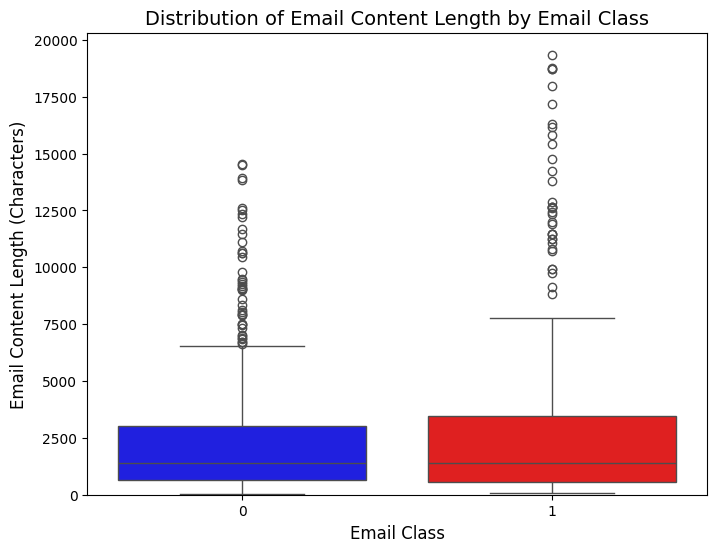

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


df['email_length'] = df['email_content'].str.len()

plt.figure(figsize=(8, 6))

sns.boxplot(
    x='spam',
    y='email_length',
    data=df,
    # Use custom colors for clarity
    palette=['blue', 'red']
)

# Add titles and labels for readability
plt.title('Distribution of Email Content Length by Email Class', fontsize=14)
plt.xlabel('Email Class', fontsize=12)
plt.ylabel('Email Content Length (Characters)', fontsize=12)

# Ensure the plot starts at zero
plt.ylim(bottom=0)
plt.show() # Note: In a production script, you'd only use savefig()


In [6]:
high_risk_spam_words = [
    'free',
    'act now',
    'urgent',
    'buy now',
    'limited time',
    'guaranteed',
    'click here',
    'make money fast',
    'earn extra cash',
    'million dollars',
    'cash bonus',
    'double your income',
    'risk-free',
    'no hidden costs',
    'miracle',
    'unbelievable',
    'amazing results',
    'as seen on',
    'no cost',
    'no catch',
    'no obligation',
    'congratulations',
    'you are a winner',
    'selected specially',
    'exclusive deal',
    'dear friend',
    'confidential',
    'private',
    'lose weight',
    'xanax',
    'prescription',
    'reverses aging',
    'final hours',
    'while supplies last',
    'last chance',
    'today only',
    'all new',
    'best price',
    'save big money',
    '$$$'
]

In [9]:
def count_spam_words(email_text):
    if pd.isna(email_text):
        return 0
    count = 0
    for word in high_risk_spam_words:
        if ' '+word+' ' in str(email_text).lower():
            count+=1
    
    return count

In [10]:
df_copy['spam_word_count'] = df['email_content'].apply(count_spam_words)
df_copy.head(n=15)

,filename,email_content,spam,subject,spam_word_count
0,6-14msg3.txt,\norganize combination colloquium work seminar...,0,Subject: wkshp : * early * - e ( = ) uralic in...,0
1,6-110msg1.txt,\njob announcement institute history philology...,0,Subject: job announcement - academium sinica,0
2,9-63msg1.txt,\nassociation language awareness knowledge lan...,0,Subject: knowledge language bibliography,1
3,spmsga95.txt,\ndue significant rapid policy change recently...,1,Subject: service update,0
4,6-97msg1.txt,\njob announcement department foreign language...,0,Subject: job announcement,0
5,8-887msg1.txt,\nalle interessentinnen und interessenten von ...,0,Subject: hypermedium den geisteswissenschaften,0
6,spmsgb16.txt,"\nsanta onlinenow wish happy holiday , merry c...",1,Subject: season greeting santa !,0
7,6-830msg1.txt,"\nshoebox content - length : 298 is , fact que...",0,"Subject: re : 6 . 823 , qs : german , nostrati...",0
8,9-612msg1.txt,\n1998 hokan - penutian conference university ...,0,Subject: hokan - penutian conference,0
9,spmsga161.txt,\nmessage send compliance propose federal legi...,1,Subject: futuresignal,1


In [11]:
correlation_matrix = df_copy[['spam_word_count', 'spam']].corr()
r_value = correlation_matrix.loc['spam_word_count', 'spam']
print(f"Correlation Coefficient (R-value): {r_value:.4f}")

Correlation Coefficient (R-value): 0.5564


Moderate/Strong correlation

# 4.Prepare the Data


Apply any data transformations and explain what and why


In [99]:
from sklearn.model_selection import train_test_split
import numpy as np 
features = ['subject', 'email_content', 'spam_word_count'] # inclduing file name is data leak
X = df_copy[features]

Y = df_copy['spam']
Y = pd.DataFrame(Y)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y,
    random_state=42
)

In [100]:
X_train.head()

,subject,email_content,spam_word_count
848,Subject: business loan & lease equipment,\nbusiness need cash loan ? fast fundings ! ! ...,0
460,Subject: lectureship linguistic,\ns c h o o l o f e n g l s h n d l n g u s t ...,0
143,Subject: pragma99,\n2nd call paper pragma99 international pragma...,0
134,Subject: 95 . 8 capital fm,\nn't want receive e-mail ? = 20 click follow ...,0
146,Subject: urgent attention,"\n' re still happy job , ' re read email ? sea...",3


In [101]:
y_train.head()

,spam
848,1
460,0
143,0
134,1
146,1


# 5. Model the data
Using selected ML models, experment with your choices and describe your findings. Finish by selecting a Model to continue with


In [102]:
from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.impute import SimpleImputer 
preprocessor = ColumnTransformer(
    transformers=[
        ('subj_vec', CountVectorizer(), 'subject'), 
        ('text_vec', CountVectorizer(), 'email_content'),
        ('numeric', SimpleImputer(strategy='constant', fill_value=0), ['spam_word_count']) 
    ],
    remainder='drop' 
)

In [103]:
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score
NBmodel = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier', MultinomialNB())
])

NBmodel.fit(X_train, y_train)
NBaccuracy = NBmodel.score(X_test, y_test)
print("MultinomialNB Accuracy", NBaccuracy)

MultinomialNB Accuracy 0.9828571428571429


/opt/tljh/user/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


 Very strong start. Stick with this model to finetune it, no Data Leaks

In [104]:
import joblib
joblib.dump(NBmodel, 'NBmodel.joblib')

['NBmodel.joblib']

# 6. Fine Tune the Model

With the select model descibe the steps taken to acheve the best rusults possiable 


In [87]:
# Test if spam_word_count is needed
from sklearn.model_selection import train_test_split
import numpy as np 
features = ['subject', 'email_content']
X = df_copy[features]

Y = df_copy['spam']
Y = pd.DataFrame(Y)

X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.2, stratify=Y,
    random_state=42
)
preprocessor = ColumnTransformer(
    transformers=[
        ('subj_vec', CountVectorizer(), 'subject'), 
        ('text_vec', CountVectorizer(), 'email_content')
    ],
    remainder='drop' 
)
NBmodel_new = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier', MultinomialNB())
])

NBmodel_new.fit(X_train, y_train)
NBaccuracy = NBmodel_new.score(X_test, y_test)
print("MultinomialNB Accuracy", NBaccuracy)

MultinomialNB Accuracy 0.9828571428571429


/opt/tljh/user/lib/python3.10/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Count Vectorization is word frequencies, so spam_word_count is a redundant feature according to accuracy
However, upon testing this data with real life emails in the inference function, spam_word_count actually
helps more than just plain text

# 7. Present
In a customer faceing Document provide summery of finding and detail approach taken


We loaded the content and separated the subject and the body of the email, putting them in a DataFrame. In addition
we had a feature that gave a list of words that were spam triggers. We kept it in after deciding it helps with different kinds of emails.
Because the filenames indicated spam or ham, we left it out of the training sets, and kept subject, body, and calculated number of spam triggers. Our first model was a MultinomialNB, where we counted tokens of what words or phrases appeared the most in each spam/ham, returning a strong 98 percent accuracy. We tried the model without spam triggers and got a very similar accuracy. However, we decided to keep it becuase the count_spam_words can work through cleaner emails. If we had more time, it would have been focused on learning how to clean and sort through the raw data to have better applications.

# 8. Launch the Model System
Define your production run code, This should be self susficent and require only your model pramaters 


In [107]:
def count_spam_words(email_text):
    if pd.isna(email_text):
        return 0
    count = 0
    for word in high_risk_spam_words:
        if ' '+word+' ' in str(email_text).lower():
            count+=1
    
    return count

In [110]:
import pandas as pd
import joblib
import numpy as np
def inference(subject, body):
    model = joblib.load('/home/jupyter-259941/Project_4/NBmodel.joblib')
    X_single = pd.DataFrame({ # Split Data and gather wanted features
    "subject":     [str(subject)],
    "email_content":     [str(body)]
    })

    X_single['spam_word_count'] = X_single['email_content'].apply(count_spam_words)
    results = model.predict(X_single)
    return results
    

In [116]:
print(inference('Supplementals','Hi Ms. Lewin! I submitted my UCF application and I just need my spark form done. If I have credits from middle school/FLVS, do I put them under American heritage or separate school?'))

[0]
